In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
sns.set_style("whitegrid")
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
path = "/content/drive/MyDrive/Colab Notebooks/data/"
movies = pd.read_csv(path+"movie.csv")
ratings = pd.read_csv(path+"rating.csv")

In [6]:
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (27278, 3)
Ratings shape: (20000263, 4)


# Nazwy kolumn

In [7]:
movies.info()
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 610.4+ MB


# **Sprawdzenie pustych wartości**

In [8]:
movies.isnull().sum()
ratings.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [9]:
ratings["rating"].describe()

,rating
count,2.000026e+07
mean,3.525529e+00
std,1.051989e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


# Rozkład ocen filmów

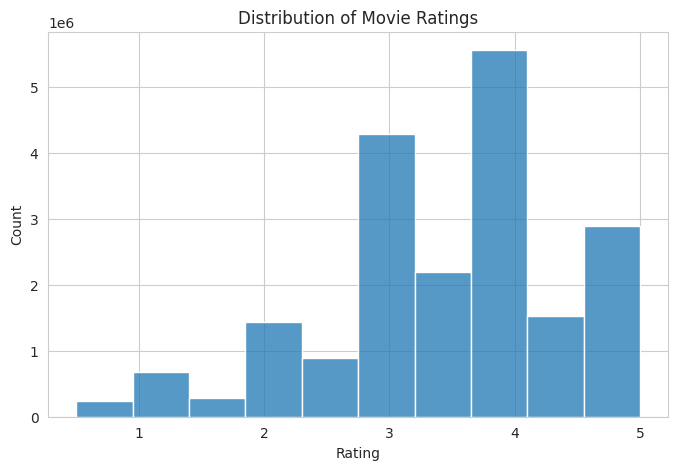

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(ratings["rating"], bins=10)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# 10 Najpopularniejszych filmów

In [23]:
popular_movies = ratings.groupby("movieId")["rating"].count().sort_values(ascending=False)
popular_movies = popular_movies.reset_index()  # zamiana indexu na kolumnę
popular_movies.columns = ["movieId", "num_ratings"]  # nadajemy nazwy kolumn

# Łączymy z tabelą movies, żeby mieć tytuły
popular_movies = popular_movies.merge(movies, on="movieId")

# Wyświetlamy top 10
popular_movies[["title", "num_ratings"]].head(10)

,title,num_ratings
0,Pulp Fiction (1994),67310
1,Forrest Gump (1994),66172
2,"Shawshank Redemption, The (1994)",63366
3,"Silence of the Lambs, The (1991)",63299
4,Jurassic Park (1993),59715
5,Star Wars: Episode IV - A New Hope (1977),54502
6,Braveheart (1995),53769
7,Terminator 2: Judgment Day (1991),52244
8,"Matrix, The (1999)",51334
9,Schindler's List (1993),50054


# Rozkład średniej ocen

In [19]:
movie_avg = ratings.groupby("movieId")["rating"].mean()

movie_avg.describe()

,rating
count,26744.000000
mean,3.133200
std,0.664084
min,0.500000
25%,2.800000
50%,3.235294
75%,3.565217
max,5.000000


In [20]:
user_avg = ratings.groupby("userId")["rating"].mean()

user_avg.describe()

,rating
count,138493.000000
mean,3.627209
std,0.443030
min,0.500000
25%,3.369478
50%,3.653846
75%,3.923077
max,5.000000
